In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score

In [2]:
df = pd.read_csv("shop_smart_ecommerce.csv")

# Features Preprocessing and Transformation

In [23]:
#for converting string to float in columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df["Month"] = le.fit_transform(df["Month"])
df["VisitorType"] = le.fit_transform(df["VisitorType"])

#converting Bollean value to float
df["Weekend"] = df["Weekend"].astype(float)
df["Revenue"] = df["Revenue"].astype(float)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  int64  
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

# EDA - Exploratory Data Analysis

Text(0.5, 1.0, 'Is product Sale or Not')

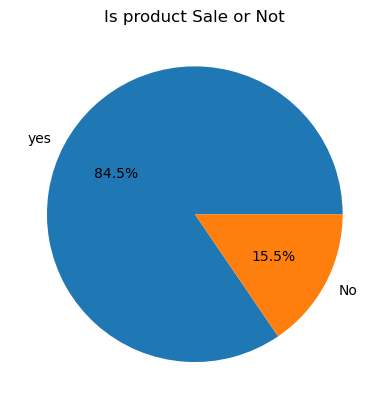

In [120]:
#Checking sale 
revenue_count = df["Revenue"].value_counts()

plt.pie(revenue_count, labels=["yes", "No"], autopct="%1.1f%%")
plt.title("Is product Sale or Not")

[Text(0, 0, '9462'), Text(0, 0, '2868')]

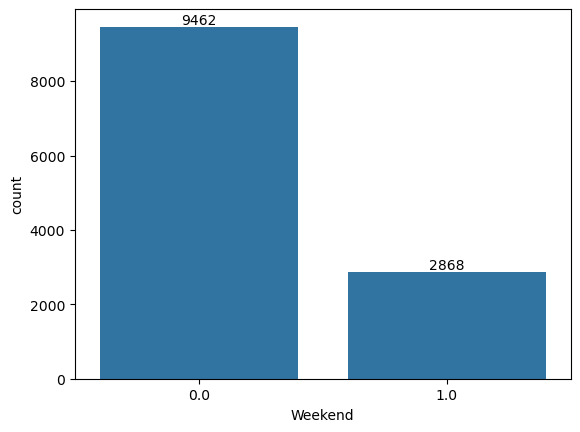

In [115]:
#cheking sale base on weekend
Weekend_count = df["Weekend"].value_counts()

plot = sns.barplot(Weekend_count)
plot.bar_label(plot.containers[0])

# Train Test Split

In [48]:
#X and Y for model
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [52]:
X

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,2,1,1,1,1,2,0.0
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,2,2,2,1,2,2,0.0
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,2,4,1,9,3,2,0.0
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,2,3,2,2,4,2,0.0
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,2,3,3,1,4,2,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,1,4,6,1,1,2,1.0
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,7,3,2,1,8,2,1.0
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,7,3,2,1,13,2,1.0
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,7,2,2,3,11,2,0.0


# Train, Decision Tree Model & Plot Tree

In [97]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [107]:
y_pred = model.predict(X_test)

print("f1_score =",f1_score(y_test, y_pred))

f1_score = 0.6045883940620783


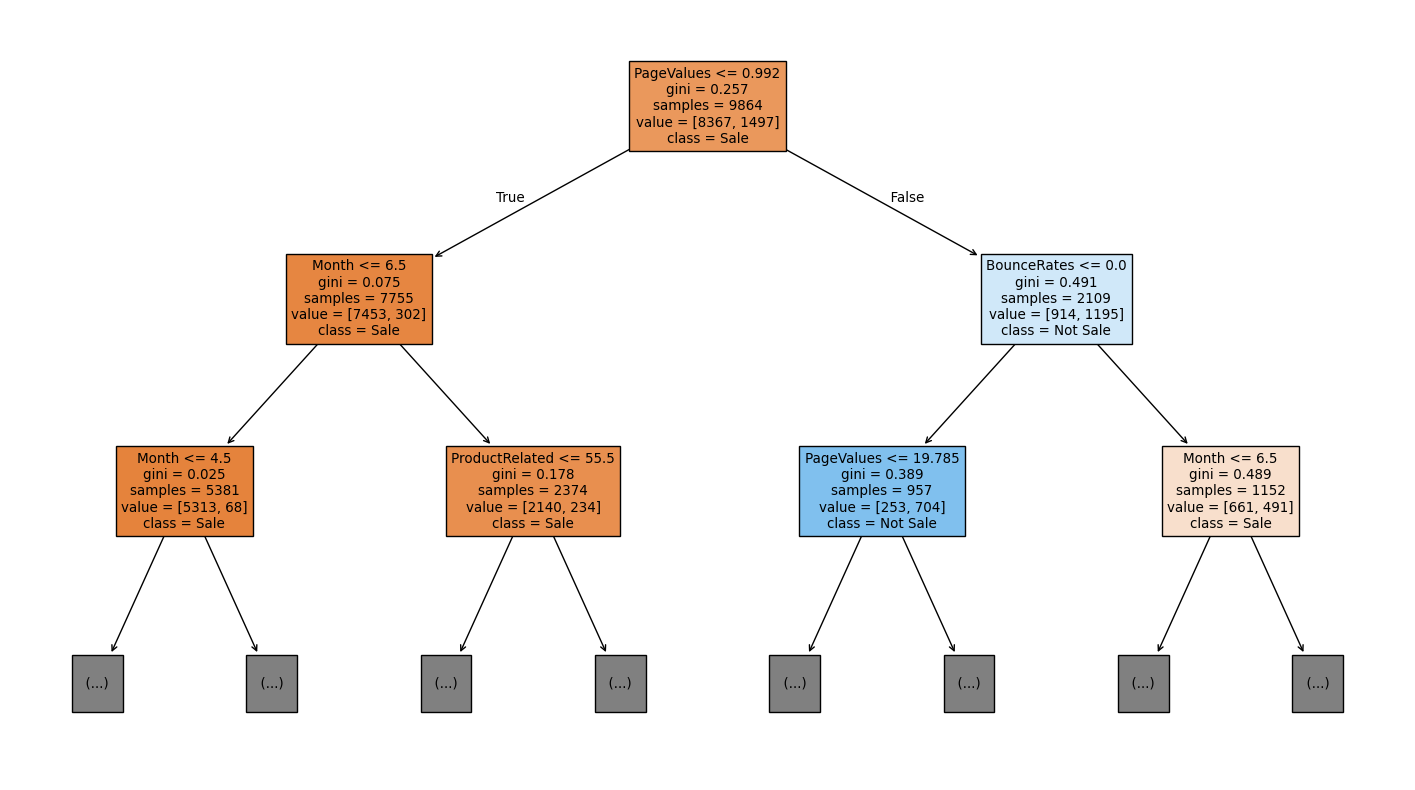

<Figure size 640x480 with 0 Axes>

In [101]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Sale", "Not Sale"],
    filled=True,
    max_depth=2
    
)
plt.show()
plt.tight_layout()

# pre-pruning

In [105]:
max_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10,]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)

    print(f"for depth = {depth}. f1_score = {f1}")

for depth = 2. f1_score = 0.5256609642301711
for depth = 3. f1_score = 0.6436781609195402
for depth = 4. f1_score = 0.6308724832214765
for depth = 5. f1_score = 0.5744047619047619
for depth = 6. f1_score = 0.6238286479250335
for depth = 7. f1_score = 0.6187845303867403
for depth = 8. f1_score = 0.6248256624825662
for depth = 9. f1_score = 0.6098901098901099
for depth = 10. f1_score = 0.6103542234332425
for depth = 11. f1_score = 0.6045883940620783


# Best f1_score

In [108]:
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("f1_score =",f1_score(y_test, y_pred))

f1_score = 0.6436781609195402


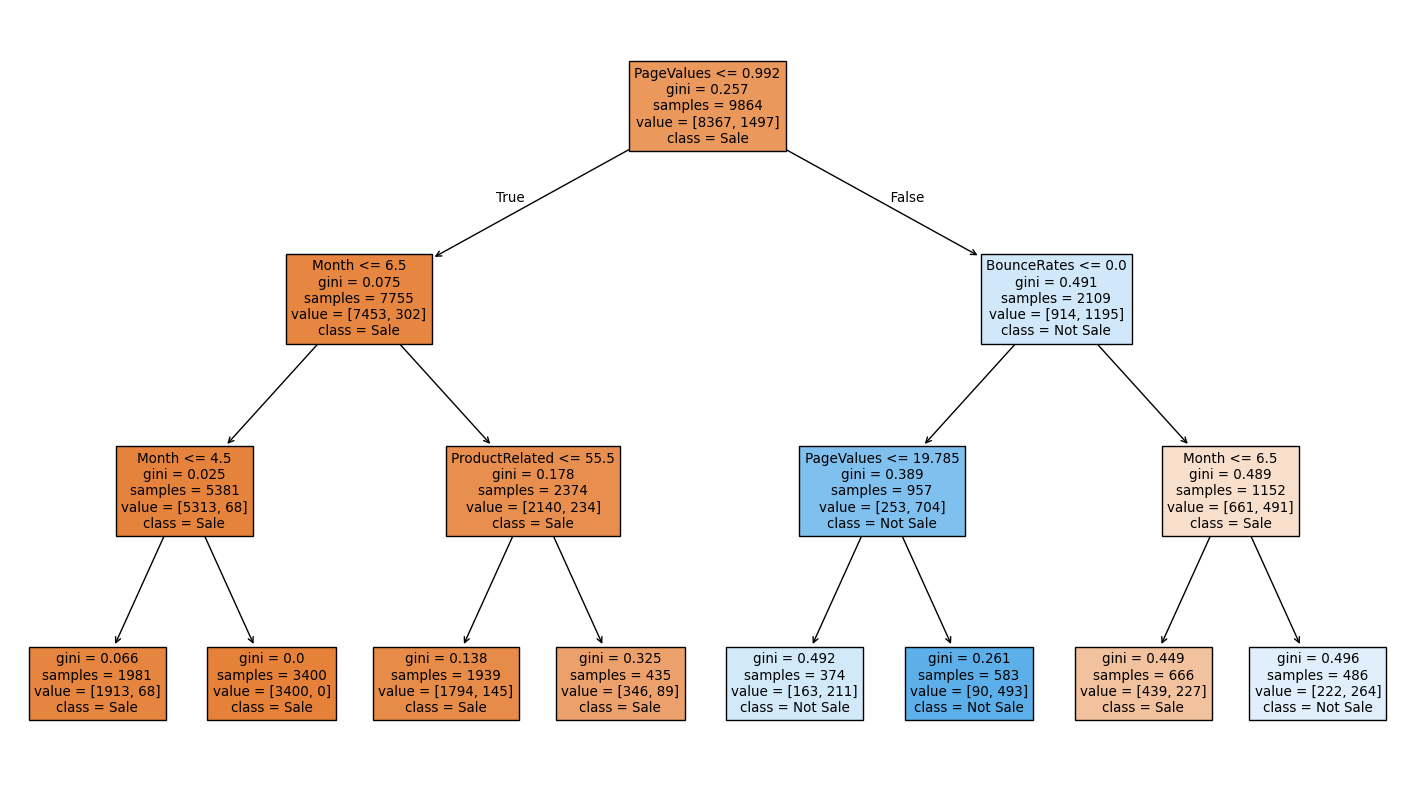

f1_score = 0.6436781609195402


<Figure size 640x480 with 0 Axes>

In [111]:
plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Sale", "Not Sale"],
    filled=True
    
)
plt.show()
plt.tight_layout()
print("f1_score =",f1_score(y_test, y_pred))